## Supplementary Figure 2

Note: This notebook requires the following simulation outputs (see `simulations.md` for run commands):

- `out/supp_fig2_randfb_assembly/`: random feedback per assembly, 5 seeds
- `out/supp_fig2_randfb_neuron/`: random feedback per neuron, 5 seeds
- `out/fig4_bcp/`: optimal feedback (Figure 4 networks), 5 seeds

In [9]:
from pathlib import Path

import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import spiffyplots
from spiffyplots import MultiPanel
from matplotlib.colors import to_rgba

mpl.style.use('spiffy')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",})

from bcp.analysis import HydraMultirun

repo_root = next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "bcp").is_dir())

#### Directory setup

In [10]:
run_dirs = {
    'optimal': repo_root / "out" / "fig4_bcp",
    'random_assembly': repo_root / "out" / "supp_fig2_randfb_assembly",
    'random_neuron': repo_root / "out" / "supp_fig2_randfb_neuron",
}

sfig2_dir = repo_root / "figures" / "supp_fig2"
sfig2_dir.mkdir(parents=True, exist_ok=True)

#### Plotting parameters

In [11]:
cm = 1 / 2.54

singlecolwidth = 8.5 * cm
onehalfcolwidth = 11.4 * cm
doublecolwidth = 17.4 * cm

color_exc = '#CD2027'
color_inh = '#0077B8'
color_inh_ff = '#57CAF1'
color_inputs = '#808285'
color_openloop = 'gray'
color_closedloop = '#F49F1E'
color_target = 'black'
color_accent = 'black'
color_shading = 'gray'

linewidth = 1.0

### Load runs

In [12]:
tables = {}
for name, path in run_dirs.items():
    table = HydraMultirun(path, result_files=['results.pkl']).table(
        keys=['OL_R2', 'CL_error', 'OL_loss', 'training_time'])
    tables[name] = {
        'R2': np.stack(table['OL_R2']),
        'FB': np.abs(np.stack(table['CL_error'])).mean(-1),
        'LOSS': np.stack(table['OL_loss']),
    }
X_TRAINING = table['training_time'][0]

### Panels b-d, f-h: training with random feedback

In [21]:
figsize_perf = (12*cm, 2.6*cm)
xticks_time = [0, 180, 360]
ylim_loss = (1e-3, 1e0)
ylim_feedback = (1e0, 1e3)

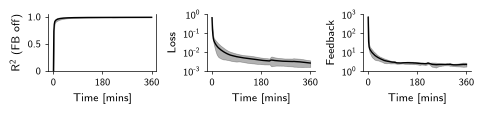

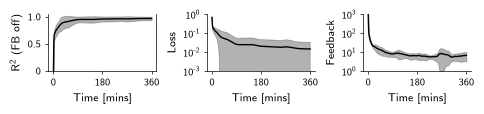

In [22]:
for name, panels in [('random_assembly', 'b-d_performance_random_per_assembly'),
                     ('random_neuron', 'f-h_performance_random_per_neuron')]:
    fig = MultiPanel(grid=[3], figsize=figsize_perf, width_ratios=[1, 1, 1])

    for ax, key in zip(fig.panels, ['R2', 'LOSS', 'FB']):
        mean, std = tables[name][key].mean(0), tables[name][key].std(0)
        ax.plot(X_TRAINING, mean, color='black', lw=linewidth)
        ax.fill_between(X_TRAINING, mean - std, mean + std, color='black', alpha=0.3)
        ax.set_xlabel('Time [mins]')
        ax.set_xticks(xticks_time)
        ax.set_xticklabels(xticks_time)

    ax = fig.panels[0]
    ax.set_ylim(1e-1, 1.05)
    ax.spines['right'].set_visible(True)
    ax.set_ylabel(r'$R^2$ (FB off)', fontsize=8)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels([0, 0.5, 1.0])

    ax = fig.panels[1]
    ax.set_ylabel(r'Loss', fontsize=8)
    ax.set_yscale('log')
    ax.set_ylim(ylim_loss)
    ax.set_yticks([1e-3, 1e-2, 1e-1, 1e0])
    ax.set_yticklabels([r'10\textsuperscript{-3}', r'10\textsuperscript{-2}', r'10\textsuperscript{-1}', r'10\textsuperscript{0}'])

    ax = fig.panels[2]
    ax.set_ylabel(r'Feedback', fontsize=8)
    ax.set_yscale('log')
    ax.set_ylim(ylim_feedback)
    ax.set_yticks([1e0, 1e1, 1e2, 1e3])
    ax.set_yticklabels([r'10\textsuperscript{0}', r'10\textsuperscript{1}', r'10\textsuperscript{2}', r'10\textsuperscript{3}'])

    plt.savefig(sfig2_dir / f'{panels}.pdf', bbox_inches='tight')
    plt.show()

### Panel i: final loss

In [15]:
figsize_final_loss = (8*cm, 4*cm)

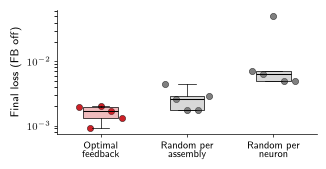

In [16]:
def swarm_box_plot(data_list, labels, figsize, colors, box_width=0.4, box_alpha=0.3,
                   jitter_x=0.5, point_size=20, point_alpha=1.0, ylabel=None):
    # also sets the rcParams used by all later panels
    plt.rcParams.update({
        'font.size': 8,
        'axes.linewidth': 0.5,
        'axes.labelsize': 8,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'xtick.major.width': 0.5,
        'ytick.major.width': 0.5,
        'xtick.major.size': 2,
        'ytick.major.size': 2,
        'lines.linewidth': 0.75,
    })
    fig, ax = plt.subplots(figsize=figsize)
    positions = np.arange(len(data_list))

    for pos, data, color in zip(positions, data_list, colors):
        ax.boxplot([data], positions=[pos], widths=box_width, patch_artist=True, showfliers=False,
                   boxprops=dict(facecolor=to_rgba(color, box_alpha), edgecolor='black', linewidth=0.5),
                   whiskerprops=dict(linewidth=0.5, color='black'),
                   medianprops=dict(linewidth=0.75, color='black'),
                   capprops=dict(linewidth=0.5, color='black'))
        x_jittered = np.linspace(pos - jitter_x / 2, pos + jitter_x / 2, len(data))
        ax.scatter(x_jittered, data, s=point_size, color=color, alpha=point_alpha,
                   edgecolor='black', linewidth=0.3)

    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    return fig, ax


fig, ax = swarm_box_plot(
    [tables[k]['LOSS'][:, -1] for k in ['optimal', 'random_assembly', 'random_neuron']],
    ['Optimal\nfeedback', 'Random per\nassembly', 'Random per\nneuron'],
    figsize=figsize_final_loss,
    colors=[color_exc, 'gray', 'gray'],
    ylabel=r'Final loss (FB off)',
)
ax.set_yscale('log')

plt.savefig(sfig2_dir / 'i_final_loss.pdf', bbox_inches='tight')
plt.show()